# 06 — Analysis of processed AQUATIME CSV files

Same pipeline as notebook 05, but reads the **AQUATIME convolved CSVs**  
(`AQUATIME_D2.1.0_RD-belgian-coast-chime-convolved-5nm-v0.1`, `10nm`, `lstm`).  

The reader handles the `icase` index column and float-named wavelength columns automatically.

## 0 — Configuration: register your CSV files here

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from phytospec.algorithms import compute_MALH, compute_CHL, compute_D2, lubac_phaeo_index
from phytospec import config as cfg

# ── Register CSV files here ───────────────────────────────────────────────────
# Each entry: (file_path, label, delta_nm)
# For lstm-convolved the delta is 10 nm; adjust if needed
FILES = [
    (cfg.DATA_RAW / "CHIME"/  "AQUATIME_D2.1.0_RD-belgian-coast-chime-convolved-5nm-v0.1",
     "aquatime_5nm",  5.0),
    (cfg.DATA_RAW / "CHIME"/  "AQUATIME_D2.1.0_RD-belgian-coast-chime-convolved-10nm-v0.1",
     "aquatime_10nm", 10.0),
    #(cfg.DATA_RAW / "CHIME"/  "AQUATIME_D2.1.0_RD-belgian-coast-lstm-convolved-v0.1",
    # "aquatime_lstm", 10.0),
    # Add more CSVs here:
    # (Path(r"C:\path\to\file"), "my_label", delta_nm),
]

# ── Output directory ──────────────────────────────────────────────────────────
FIG_DIR = cfg.DATA_PROCESSED / "figures_aquatime"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── In-situ reference (PANTHYR RT1) ──────────────────────────────────────────
INSITU_REF = {
    "malh_phaeo_median": 0.005,
    "malh_threshold":    0.003,
    "malh_dominance":    0.010,
    "delta_nm":          2.5,
}

print(f"Files registered: {len(FILES)}")
for fpath, label, delta in FILES:
    # Try both with and without .csv extension
    found = next((p for p in [Path(fpath), Path(str(fpath)+'.csv')] if p.exists()), None)
    status = f'✓  ({found.suffix or "no ext"})' if found else '✗ NOT FOUND'
    print(f"  {status}  {label}  (delta={delta} nm)")

Files registered: 2
  ✓  (.csv)  aquatime_5nm  (delta=5.0 nm)
  ✓  (.csv)  aquatime_10nm  (delta=10.0 nm)


## 1 — Process all CSV files

In [8]:
def read_aquatime_csv(filepath):
    """
    Reads an AQUATIME convolved CSV.
    Handles files with or without .csv extension.
    Expects:
      - Column 'icase' (or first column) as row index
      - Wavelength columns named as floats: '350.000000', '355.000000', ...
    Returns: RHOW (N x B float array), wl (B,), icases (list of str)
    """
    filepath = Path(filepath)
    # Resolve extension
    for path in [filepath, Path(str(filepath) + '.csv')]:
        if path.exists():
            filepath = path
            break
    else:
        raise FileNotFoundError(f"Not found: {filepath}")

    df = pd.read_csv(filepath, sep=None, engine='python')

    # Identify wavelength columns: those whose name is convertible to float
    wl_cols, wl_vals = [], []
    for c in df.columns:
        try:
            wl_vals.append(float(c))
            wl_cols.append(c)
        except (ValueError, TypeError):
            pass

    if not wl_cols:
        raise ValueError(f"No wavelength columns found in {filepath.name}")

    wl    = np.array(wl_vals)
    RHOW  = df[wl_cols].values.astype(float)

    # Use icase column as identifier if present, else row index
    if 'icase' in df.columns:
        icases = list(df['icase'].astype(str))
    else:
        icases = list(df.index.astype(str))

    # Remove negative values
    RHOW[RHOW < 0] = np.nan

    return RHOW, wl, icases


def process_file(filepath, label, delta):
    """Read, QC, and compute all indices for one CSV file."""
    RHOW, wl, icases = read_aquatime_csv(filepath)
    N = len(icases)
    actual_delta = float(np.round(wl[1] - wl[0], 2))

    if abs(actual_delta - delta) > 0.1:
        print(f"  ⚠️  {label}: actual spacing {actual_delta} nm vs declared delta={delta} nm")

    # QC — drop rows with too many NaNs
    n_nan = np.sum(np.isnan(RHOW), axis=1)
    keep  = n_nan < 10
    RHOW_qc   = RHOW[keep, :]
    icases_qc = [ic for ic, k in zip(icases, keep) if k]
    N_qc      = len(icases_qc)

    CHL  = np.full(N_qc, np.nan)
    MALH = np.full(N_qc, np.nan)
    PLUB = np.zeros(N_qc, dtype=int)
    D2R  = np.full((N_qc, len(wl)), np.nan)

    for i in range(N_qc):
        rhow_i = RHOW_qc[i, :]
        if np.sum(~np.isnan(rhow_i)) < 50:
            continue
        CHL[i]    = compute_CHL(rhow_i, wl)
        MALH[i]   = compute_MALH(rhow_i, wl)
        D2R[i, :] = compute_D2(rhow_i, wl, delta=delta, n_smooth=2)
        PLUB[i]   = lubac_phaeo_index(wl, D2R[i, :])

    n_phaeo  = int(PLUB.sum())
    n_diatom = int((PLUB == 0).sum())

    malh_p = MALH[PLUB == 1]
    malh_d = MALH[PLUB == 0]

    malh_phaeo_median  = float(np.nanmedian(malh_p)) if len(malh_p) > 0 else np.nan
    malh_diatom_median = float(np.nanmedian(malh_d)) if len(malh_d) > 0 else np.nan
    candidate_thr      = float(np.nanpercentile(malh_d, 75)) if len(malh_d) > 0 else np.nan
    misclass_pct       = float(np.mean(malh_p <= candidate_thr) * 100) if len(malh_p) > 0 else np.nan

    print(f"  ✓ {label}: {N_qc} spectra | P.glob={n_phaeo} | Diatoms={n_diatom} | "
          f"CHL valid={int(np.sum(~np.isnan(CHL)))}")

    return {
        "label":      label,
        "delta":      actual_delta,
        "N":          N_qc,
        "n_phaeo":    n_phaeo,
        "n_diatom":   n_diatom,
        "pct_phaeo":  round(n_phaeo / N_qc * 100, 1),
        "chl_valid":  int(np.sum(~np.isnan(CHL))),
        "CHL":        CHL,
        "MALH":       MALH,
        "PLUB":       PLUB,
        "D2R":        D2R,
        "RHOW":       RHOW_qc,
        "wl":         wl,
        "malh_phaeo_median":  malh_phaeo_median,
        "malh_diatom_median": malh_diatom_median,
        "candidate_thr":      candidate_thr,
        "misclass_pct":       misclass_pct,
    }


print("Processing CSV files...")
RESULTS = []
for fpath, label, delta in FILES:
    try:
        res = process_file(fpath, label, delta)
        RESULTS.append(res)
    except FileNotFoundError:
        print(f"  ✗ SKIPPED (not found): {label}")

print(f"\nDone. {len(RESULTS)} files processed.")

Processing CSV files...
  ✓ aquatime_5nm: 779 spectra | P.glob=141 | Diatoms=638 | CHL valid=0
  ✓ aquatime_10nm: 779 spectra | P.glob=36 | Diatoms=743 | CHL valid=0

Done. 2 files processed.


## 2 — Raw spectra per file (sample ≤ 100)

  aquatime_5nm                   ρw range: 0.00016 – 0.18837
  aquatime_10nm                  ρw range: 0.00019 – 0.18766


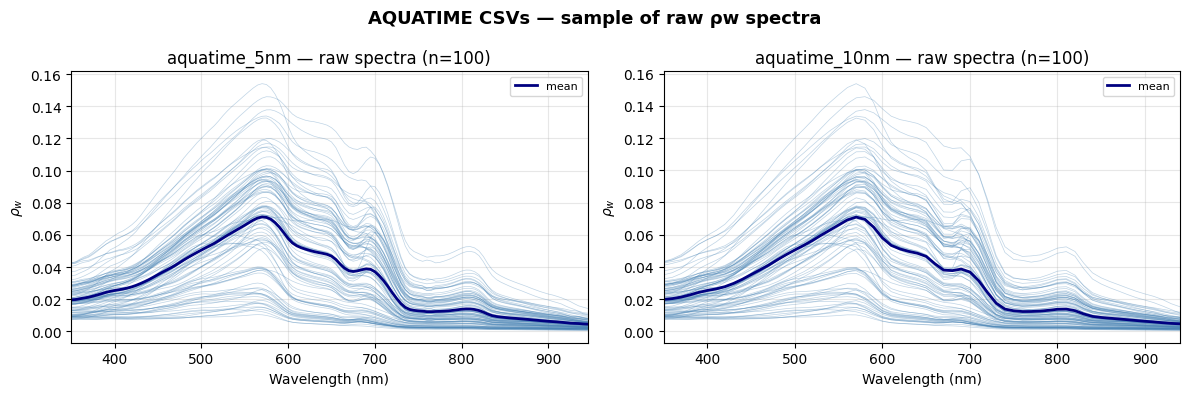


Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\processed\figures_aquatime\fig0_raw_spectra.png


In [9]:
n_files = len(RESULTS)
ncols   = min(n_files, 3)
nrows   = int(np.ceil(n_files / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
axes = np.array(axes).flatten()

for ax, r in zip(axes, RESULTS):
    wl   = r['wl']
    RHOW = r['RHOW']
    N    = RHOW.shape[0]
    plot_idx = np.linspace(0, N - 1, min(N, 100), dtype=int)
    for i in plot_idx:
        ax.plot(wl, RHOW[i, :], lw=0.5, alpha=0.35, color='steelblue')
    ax.plot(wl, np.nanmean(RHOW, axis=0), lw=2.0, color='navy', label='mean')
    ax.set(xlabel='Wavelength (nm)', ylabel=r'$\rho_w$',
           title=f"{r['label']} — raw spectra (n={len(plot_idx)})",
           xlim=(wl[0], wl[-1]))
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    print(f"  {r['label']:<30} ρw range: {np.nanmin(RHOW):.5f} – {np.nanmax(RHOW):.5f}")

for ax in axes[n_files:]:
    ax.set_visible(False)

plt.suptitle('AQUATIME CSVs — sample of raw ρw spectra', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig0_raw_spectra.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"\nSaved → {FIG_DIR / 'fig0_raw_spectra.png'}")

## 3 — Summary comparison table

In [10]:
rows = []
for r in RESULTS:
    rows.append({
        'File':                   r['label'],
        'Resolution (nm)':        r['delta'],
        'N spectra':              r['N'],
        'P. globosa (n)':         r['n_phaeo'],
        'P. globosa (%)':         r['pct_phaeo'],
        'Diatoms (n)':            r['n_diatom'],
        'CHL valid (n)':          r['chl_valid'],
        'MALH P.glob median':     round(r['malh_phaeo_median'], 5) if not np.isnan(r['malh_phaeo_median']) else '—',
        'MALH Diatom median':     round(r['malh_diatom_median'], 5),
        'Candidate threshold':    round(r['candidate_thr'], 5),
        'Misclassified (%)':      round(r['misclass_pct'], 1) if not np.isnan(r['misclass_pct']) else '—',
    })

summary_df = pd.DataFrame(rows)
print('=' * 80)
print('SUMMARY TABLE — AQUATIME CSV files')
print('=' * 80)
print(summary_df.to_string(index=False))

out_csv = FIG_DIR / 'aquatime_summary_table.csv'
summary_df.to_csv(out_csv, index=False)
print(f'\nSaved → {out_csv}')

SUMMARY TABLE — AQUATIME CSV files
         File  Resolution (nm)  N spectra  P. globosa (n)  P. globosa (%)  Diatoms (n)  CHL valid (n)  MALH P.glob median  MALH Diatom median  Candidate threshold  Misclassified (%)
 aquatime_5nm              5.0        779             141            18.1          638              0            -0.00020            -0.00252             -0.00142               37.6
aquatime_10nm             10.0        779              36             4.6          743              0             0.00253            -0.00173             -0.00103                8.3

Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\processed\figures_aquatime\aquatime_summary_table.csv


## 4 — Figure 1: Spectral signatures by Lubac class (ρw + D²)

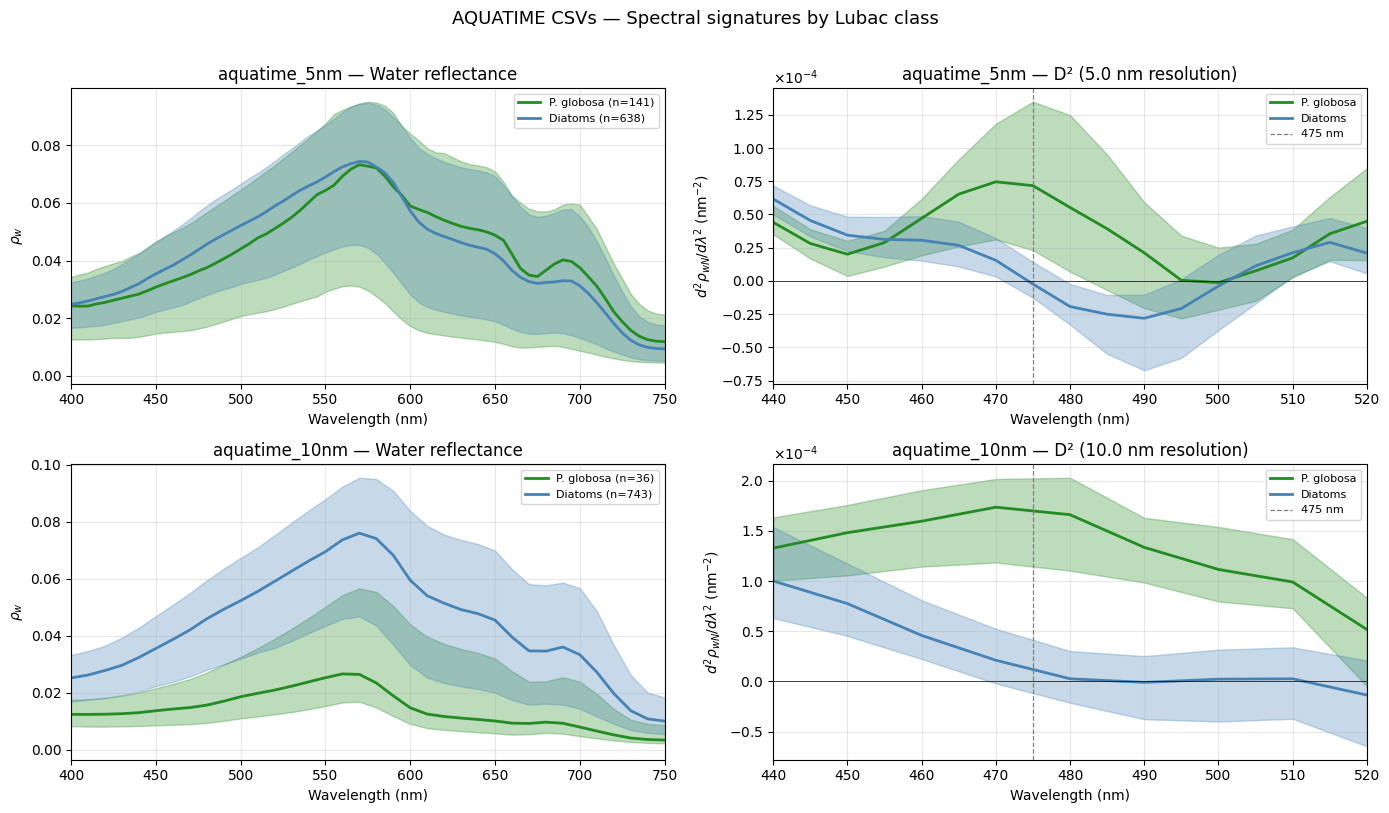

Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\processed\figures_aquatime\fig1_spectral_signatures.png


In [11]:
n_files = len(RESULTS)
fig, axes = plt.subplots(n_files, 2, figsize=(14, 4 * n_files))
if n_files == 1:
    axes = axes[np.newaxis, :]

for row, r in enumerate(RESULTS):
    wl        = r['wl']
    RHOW      = r['RHOW']
    D2R       = r['D2R']
    PLUB      = r['PLUB']
    wl_mask   = (wl >= 440) & (wl <= 520)
    d2_wl     = wl[wl_mask]
    phaeo_idx = PLUB == 1
    diatom_idx= PLUB == 0

    # ── Left: ρw ──────────────────────────────────────────────────────────────
    ax = axes[row, 0]
    if phaeo_idx.sum() > 0:
        ph = RHOW[phaeo_idx, :]
        ax.fill_between(wl,
            np.nanpercentile(ph, 25, axis=0), np.nanpercentile(ph, 75, axis=0),
            alpha=0.3, color='forestgreen')
        ax.plot(wl, np.nanmedian(ph, axis=0), color='forestgreen', lw=2,
                label=f'P. globosa (n={phaeo_idx.sum()})')
    if diatom_idx.sum() > 0:
        di = RHOW[diatom_idx, :]
        ax.fill_between(wl,
            np.nanpercentile(di, 25, axis=0), np.nanpercentile(di, 75, axis=0),
            alpha=0.3, color='steelblue')
        ax.plot(wl, np.nanmedian(di, axis=0), color='steelblue', lw=2,
                label=f'Diatoms (n={diatom_idx.sum()})')
    ax.set(xlabel='Wavelength (nm)', ylabel=r'$\rho_w$',
           title=f"{r['label']} — Water reflectance", xlim=(400, 750))
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # ── Right: D² ─────────────────────────────────────────────────────────────
    ax = axes[row, 1]
    if phaeo_idx.sum() > 0:
        ph_d2 = D2R[phaeo_idx, :][:, wl_mask]
        ax.fill_between(d2_wl,
            np.nanpercentile(ph_d2, 25, axis=0), np.nanpercentile(ph_d2, 75, axis=0),
            alpha=0.3, color='forestgreen')
        ax.plot(d2_wl, np.nanmedian(ph_d2, axis=0), color='forestgreen', lw=2,
                label='P. globosa')
    if diatom_idx.sum() > 0:
        di_d2 = D2R[diatom_idx, :][:, wl_mask]
        ax.fill_between(d2_wl,
            np.nanpercentile(di_d2, 25, axis=0), np.nanpercentile(di_d2, 75, axis=0),
            alpha=0.3, color='steelblue')
        ax.plot(d2_wl, np.nanmedian(di_d2, axis=0), color='steelblue', lw=2,
                label='Diatoms')
    ax.axvline(475, color='grey', linestyle='--', lw=0.9, label='475 nm')
    ax.axhline(0, color='k', lw=0.5)
    ax.set(xlabel='Wavelength (nm)',
           ylabel=r'$d^2\rho_{wN}/d\lambda^2$ (nm$^{-2}$)',
           title=f"{r['label']} — D² ({r['delta']} nm resolution)",
           xlim=(440, 520))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('AQUATIME CSVs — Spectral signatures by Lubac class', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_spectral_signatures.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR / "fig1_spectral_signatures.png"}')

## 5 — Figure 2: MALH distributions by Lubac class

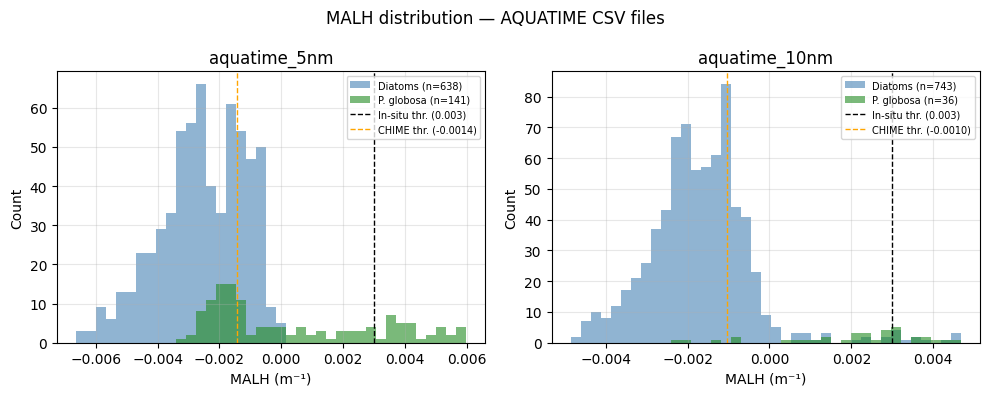

Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\processed\figures_aquatime\fig2_malh_distributions.png


In [12]:
n_files = len(RESULTS)
fig, axes = plt.subplots(1, n_files, figsize=(5 * n_files, 4), sharey=False)
if n_files == 1:
    axes = [axes]

for ax, r in zip(axes, RESULTS):
    malh_d = r['MALH'][r['PLUB'] == 0]
    malh_p = r['MALH'][r['PLUB'] == 1]
    p1, p99 = np.nanpercentile(r['MALH'], [1, 99])
    bins = np.linspace(p1, p99, 40)

    ax.hist(malh_d, bins=bins, alpha=0.6, color='steelblue',
            label=f'Diatoms (n={len(malh_d)})')
    if len(malh_p) > 0:
        ax.hist(malh_p, bins=bins, alpha=0.6, color='forestgreen',
                label=f'P. globosa (n={len(malh_p)})')

    ax.axvline(INSITU_REF['malh_threshold'], color='k', linestyle='--',
               lw=1.0, label=f'In-situ thr. ({INSITU_REF["malh_threshold"]})')
    if not np.isnan(r['candidate_thr']):
        ax.axvline(r['candidate_thr'], color='orange', linestyle='--', lw=1.0,
                   label=f'CHIME thr. ({r["candidate_thr"]:.4f})')

    ax.set(xlabel='MALH (m⁻¹)', ylabel='Count', title=r['label'])
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.suptitle('MALH distribution — AQUATIME CSV files', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_malh_distributions.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR / "fig2_malh_distributions.png"}')

## 6 — Figure 3: D² at 475 nm scatter (coloured by Lubac class)

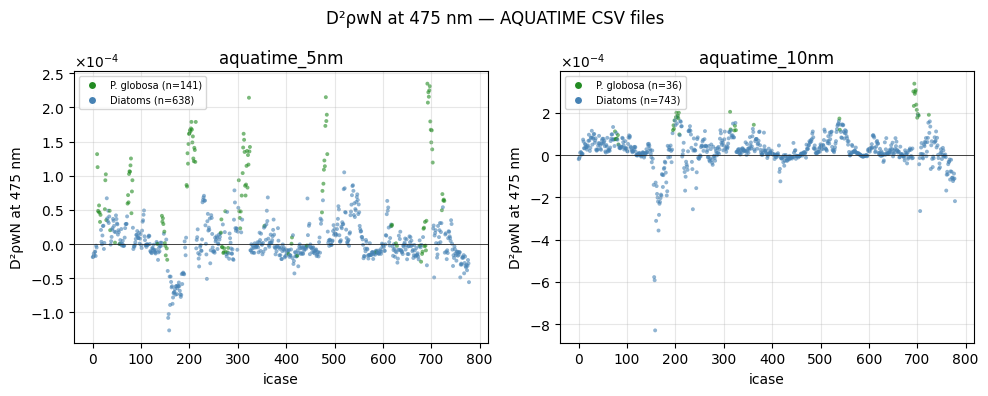

Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\processed\figures_aquatime\fig3_d2_475nm_scatter.png


In [13]:
from matplotlib.lines import Line2D

n_files = len(RESULTS)
fig, axes = plt.subplots(1, n_files, figsize=(5 * n_files, 4), sharey=False)
if n_files == 1:
    axes = [axes]

for ax, r in zip(axes, RESULTS):
    wl     = r['wl']
    idx475 = int(np.argmin(np.abs(wl - 475.0)))
    d2_475 = r['D2R'][:, idx475]
    colors = ['forestgreen' if p else 'steelblue' for p in r['PLUB']]

    ax.scatter(range(r['N']), d2_475, c=colors, s=8, alpha=0.6, linewidths=0)
    ax.axhline(0, color='k', lw=0.5)
    ax.set(xlabel='icase', ylabel='D²ρwN at 475 nm', title=r['label'])
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.grid(alpha=0.3)
    ax.legend(handles=[
        Line2D([0],[0], marker='o', color='w', markerfacecolor='forestgreen',
               markersize=6, label=f'P. globosa (n={r["n_phaeo"]})'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
               markersize=6, label=f'Diatoms (n={r["n_diatom"]})'),
    ], fontsize=7)

plt.suptitle('D²ρwN at 475 nm — AQUATIME CSV files', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_d2_475nm_scatter.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR / "fig3_d2_475nm_scatter.png"}')

## 7 — Figure 4: Algorithm performance summary

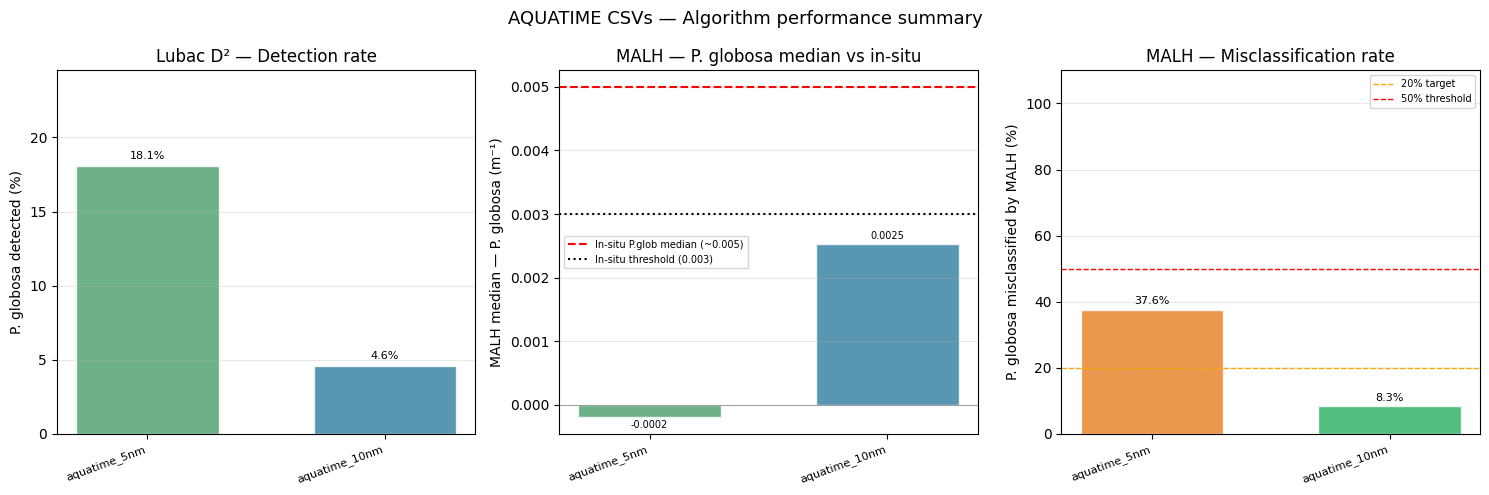

Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\processed\figures_aquatime\fig4_algorithm_performance.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

labels     = [r['label'] for r in RESULTS]
pct_phaeo  = [r['pct_phaeo'] for r in RESULTS]
malh_p_med = [r['malh_phaeo_median'] if not np.isnan(r['malh_phaeo_median']) else 0
              for r in RESULTS]
misclass   = [r['misclass_pct'] if not np.isnan(r['misclass_pct']) else 100
              for r in RESULTS]

# Colour by resolution
res_colors = ['#4a9e6b' if r['delta'] == 5.0 else
              '#2e7d9e' if r['delta'] == 10.0 else '#9b59b6'
              for r in RESULTS]

x = np.arange(len(labels))
w = 0.6

# ── Panel 1: Detection rate ───────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(x, pct_phaeo, width=w, color=res_colors, alpha=0.8, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('P. globosa detected (%)')
ax.set_title('Lubac D² — Detection rate')
ax.set_ylim(0, max(pct_phaeo) * 1.3 + 1 if max(pct_phaeo) > 0 else 10)
for bar, val in zip(bars, pct_phaeo):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── Panel 2: MALH P.glob median vs in-situ ────────────────────────────────────
ax = axes[1]
bars = ax.bar(x, malh_p_med, width=w, color=res_colors, alpha=0.8, edgecolor='white')
ax.axhline(INSITU_REF['malh_phaeo_median'], color='red', linestyle='--', lw=1.5,
           label=f'In-situ P.glob median (~{INSITU_REF["malh_phaeo_median"]})')
ax.axhline(INSITU_REF['malh_threshold'], color='k', linestyle=':', lw=1.5,
           label=f'In-situ threshold ({INSITU_REF["malh_threshold"]})')
ax.axhline(0, color='grey', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('MALH median — P. globosa (m⁻¹)')
ax.set_title('MALH — P. globosa median vs in-situ')
ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, malh_p_med):
    ypos = bar.get_height() + 0.00005 if val >= 0 else bar.get_height() - 0.0002
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:.4f}', ha='center', va='bottom', fontsize=7)

# ── Panel 3: Misclassification rate ──────────────────────────────────────────
ax = axes[2]
bar_colors_mc = ['#c0392b' if m > 50 else '#e67e22' if m > 20 else '#27ae60'
                 for m in misclass]
bars = ax.bar(x, misclass, width=w, color=bar_colors_mc, alpha=0.8, edgecolor='white')
ax.axhline(20, color='orange', linestyle='--', lw=1.0, label='20% target')
ax.axhline(50, color='red',    linestyle='--', lw=1.0, label='50% threshold')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('P. globosa misclassified by MALH (%)')
ax.set_title('MALH — Misclassification rate')
ax.set_ylim(0, 110); ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)
for bar, val, lbl in zip(bars, misclass, labels):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%' if val < 100 else 'N/A',
            ha='center', va='bottom', fontsize=8)

plt.suptitle('AQUATIME CSVs — Algorithm performance summary', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_algorithm_performance.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR / "fig4_algorithm_performance.png"}')

## 8 — Figure 5: Resolution effect — 5 nm vs 10 nm (AQUATIME)

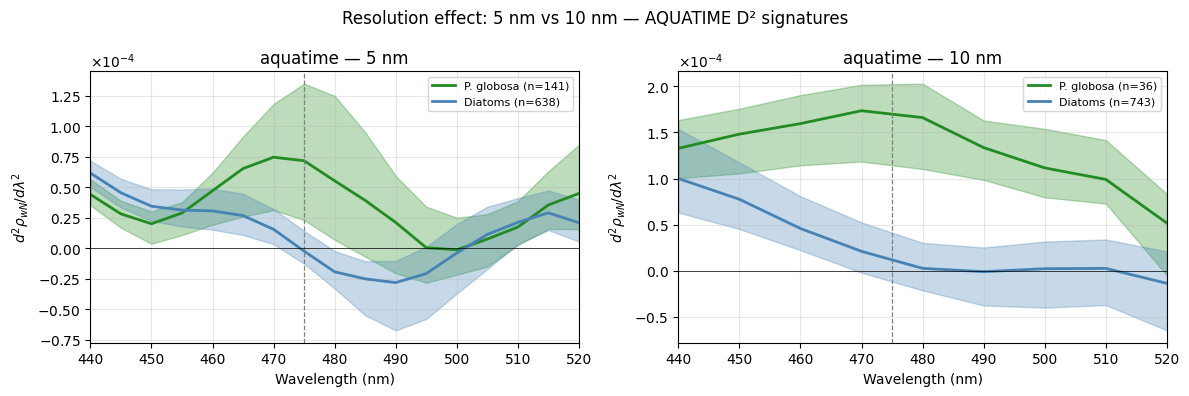

Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\processed\figures_aquatime\fig5_resolution_comparison.png


In [15]:
# Pair files by stripping resolution prefix from label
pairs = {}
for r in RESULTS:
    # aquatime_5nm → '5nm', aquatime_10nm → '10nm', aquatime_lstm → 'lstm'
    lbl = r['label']
    if r['delta'] == 5.0:
        key = lbl.replace('_5nm', '').replace('aquatime_', '')
        pairs.setdefault(key, {})['5nm'] = r
    elif r['delta'] == 10.0 and 'lstm' not in lbl:
        key = lbl.replace('_10nm', '').replace('aquatime_', '')
        pairs.setdefault(key, {})['10nm'] = r

valid_pairs = {k: v for k, v in pairs.items() if '5nm' in v and '10nm' in v}

if not valid_pairs:
    print("No matched 5nm/10nm pairs found — skipping resolution comparison.")
else:
    fig, axes = plt.subplots(len(valid_pairs), 2,
                             figsize=(12, 4 * len(valid_pairs)))
    if len(valid_pairs) == 1:
        axes = axes[np.newaxis, :]

    for row, (dataset, pair) in enumerate(valid_pairs.items()):
        for col, (res_label, r) in enumerate([('5 nm', pair['5nm']),
                                               ('10 nm', pair['10nm'])]):
            ax      = axes[row, col]
            wl      = r['wl']
            wl_mask = (wl >= 440) & (wl <= 520)
            d2_wl   = wl[wl_mask]
            phaeo_idx  = r['PLUB'] == 1
            diatom_idx = r['PLUB'] == 0

            if phaeo_idx.sum() > 0:
                ph = r['D2R'][phaeo_idx, :][:, wl_mask]
                ax.fill_between(d2_wl,
                    np.nanpercentile(ph, 25, axis=0), np.nanpercentile(ph, 75, axis=0),
                    alpha=0.3, color='forestgreen')
                ax.plot(d2_wl, np.nanmedian(ph, axis=0), color='forestgreen', lw=2,
                        label=f'P. globosa (n={phaeo_idx.sum()})')
            if diatom_idx.sum() > 0:
                di = r['D2R'][diatom_idx, :][:, wl_mask]
                ax.fill_between(d2_wl,
                    np.nanpercentile(di, 25, axis=0), np.nanpercentile(di, 75, axis=0),
                    alpha=0.3, color='steelblue')
                ax.plot(d2_wl, np.nanmedian(di, axis=0), color='steelblue', lw=2,
                        label=f'Diatoms (n={diatom_idx.sum()})')

            ax.axvline(475, color='grey', linestyle='--', lw=0.9)
            ax.axhline(0, color='k', lw=0.5)
            ax.set(xlabel='Wavelength (nm)',
                   ylabel=r'$d^2\rho_{wN}/d\lambda^2$',
                   title=f'{dataset} — {res_label}', xlim=(440, 520))
            ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
            ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
            ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.suptitle('Resolution effect: 5 nm vs 10 nm — AQUATIME D² signatures',
                 fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig5_resolution_comparison.png', dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved → {FIG_DIR / "fig5_resolution_comparison.png"}')

---
## 9 — MALH band alignment diagnostic

Identifies which exact CHIME band centres are used by MALH at each resolution,
and computes the effective baseline slope — to diagnose the sign inversion at 5 nm.

MALH BAND ALIGNMENT DIAGNOSTIC
  Reference wavelengths (PANTHYR 2.5 nm grid):
    Baseline left  : 667.0 nm
    Peak           : 681.0 nm
    Baseline right : 715.0 nm

──────────────────────────────────────────────────────────────────────
  File: aquatime_5nm  (Δλ = 5.0 nm)
──────────────────────────────────────────────────────────────────────
            left  target=667.0 nm  →  nearest band=665.0 nm  (offset=-2.0 nm)
            peak  target=681.0 nm  →  nearest band=680.0 nm  (offset=-1.0 nm)
           right  target=715.0 nm  →  nearest band=715.0 nm  (offset=+0.0 nm)

    Mean spectrum decomposition:
      ρw at left  (665.0 nm) = 0.03933
      ρw at peak  (680.0 nm) = 0.03763
      ρw at right (715.0 nm) = 0.02796
      Baseline fraction t = (680.0 - 665.0) / (715.0 - 665.0) = 0.3000
      Baseline value at peak = 0.03592
      MALH = ρw_peak - baseline = +0.00171  ← sign OK ✓
      Baseline slope (left→right) = -0.000227 sr⁻¹/nm  (falling ↘)


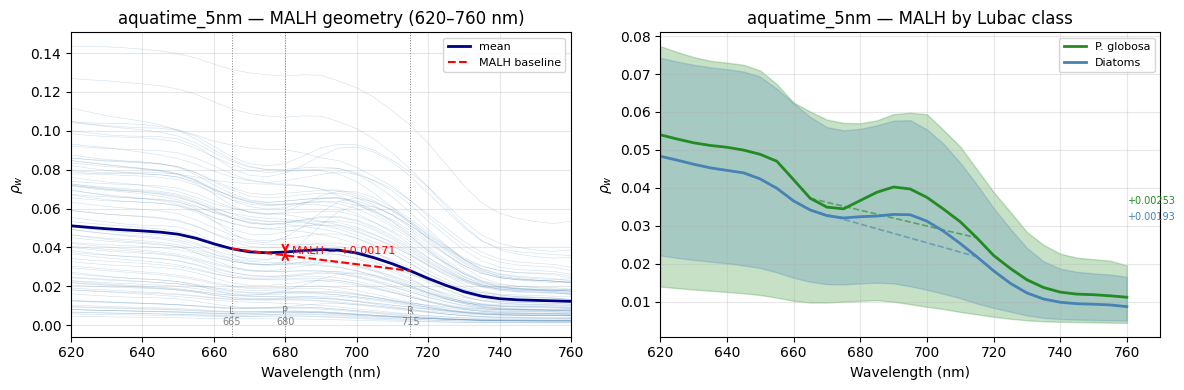

  Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\processed\figures_aquatime\malh_diagnostic_aquatime_5nm.png

──────────────────────────────────────────────────────────────────────
  File: aquatime_10nm  (Δλ = 10.0 nm)
──────────────────────────────────────────────────────────────────────
            left  target=667.0 nm  →  nearest band=670.0 nm  (offset=+3.0 nm)
            peak  target=681.0 nm  →  nearest band=680.0 nm  (offset=-1.0 nm)
           right  target=715.0 nm  →  nearest band=710.0 nm  (offset=-5.0 nm)

    Mean spectrum decomposition:
      ρw at left  (670.0 nm) = 0.03802
      ρw at peak  (680.0 nm) = 0.03772
      ρw at right (710.0 nm) = 0.03143
      Baseline fraction t = (680.0 - 670.0) / (710.0 - 670.0) = 0.2500
      Baseline value at peak = 0.03637
      MALH = ρw_peak - baseline = +0.00135  ← sign OK ✓
      Baseline slope (left→right) = -0.000165 sr⁻¹/nm  (falling ↘)


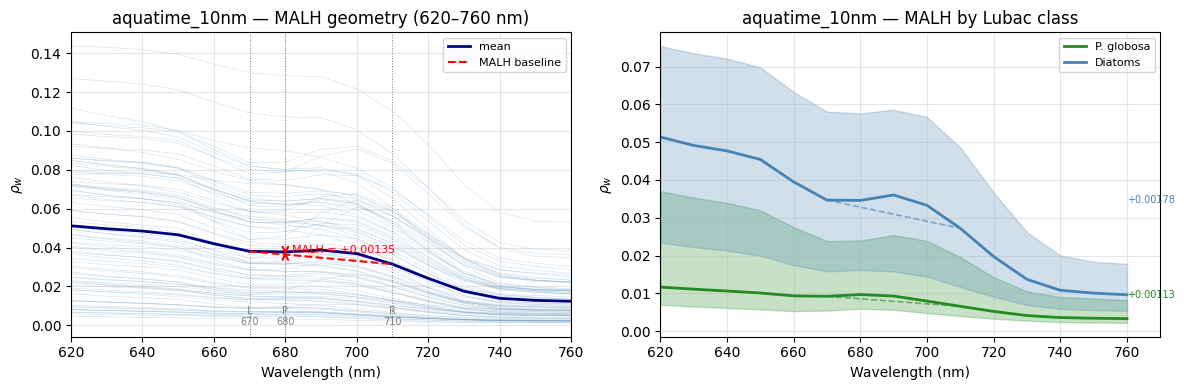

  Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\processed\figures_aquatime\malh_diagnostic_aquatime_10nm.png

SUMMARY: MALH sign diagnosis
  If baseline slope is RISING (ρw_right > ρw_left) and the peak band
  falls below the interpolated baseline → MALH < 0.
  This happens when CHIME band centres shift the effective 'left' and
  'right' anchors onto different spectral slopes than PANTHYR at 2.5 nm.
  Fix options:
    1. Snap MALH wavelengths to nearest actual CHIME band centres
    2. Recalibrate left/peak/right wavelengths per resolution
    3. Use a signed MALH with resolution-specific threshold


In [17]:
# ── MALH reference wavelengths (from Astoreca formulation) ────────────────────
# MALH = Rrs(681) - Rrs(667) - [Rrs(715) - Rrs(667)] * (681-667)/(715-667)
# i.e. a line-height at 681 nm between baseline points 667 nm and 715 nm
MALH_WL = {"left": 667.0, "peak": 681.0, "right": 715.0}

print("=" * 70)
print("MALH BAND ALIGNMENT DIAGNOSTIC")
print("=" * 70)
print(f"  Reference wavelengths (PANTHYR 2.5 nm grid):")
print(f"    Baseline left  : {MALH_WL['left']} nm")
print(f"    Peak           : {MALH_WL['peak']} nm")
print(f"    Baseline right : {MALH_WL['right']} nm")

for r in RESULTS:
    wl   = r['wl']
    RHOW = r['RHOW']
    print(f"\n{'─'*70}")
    print(f"  File: {r['label']}  (Δλ = {r['delta']} nm)")
    print(f"{'─'*70}")

    # Find nearest band centre for each MALH reference wavelength
    for name, wl_ref in MALH_WL.items():
        idx    = int(np.argmin(np.abs(wl - wl_ref)))
        actual = wl[idx]
        offset = actual - wl_ref
        flag   = "  ← ⚠ offset > Δλ/2!" if abs(offset) > r['delta'] / 2 else ""
        print(f"    {name:>12s}  target={wl_ref:.1f} nm  →  nearest band={actual:.1f} nm  "
              f"(offset={offset:+.1f} nm){flag}")

    # Compute mean MALH decomposition across all spectra
    i_left  = int(np.argmin(np.abs(wl - MALH_WL['left'])))
    i_peak  = int(np.argmin(np.abs(wl - MALH_WL['peak'])))
    i_right = int(np.argmin(np.abs(wl - MALH_WL['right'])))

    rrs_left  = np.nanmean(RHOW[:, i_left])
    rrs_peak  = np.nanmean(RHOW[:, i_peak])
    rrs_right = np.nanmean(RHOW[:, i_right])

    wl_left  = wl[i_left]
    wl_peak  = wl[i_peak]
    wl_right = wl[i_right]

    # Baseline value at peak wavelength by linear interpolation
    t         = (wl_peak - wl_left) / (wl_right - wl_left)
    baseline  = rrs_left + t * (rrs_right - rrs_left)
    malh_mean = rrs_peak - baseline

    print(f"\n    Mean spectrum decomposition:")
    print(f"      ρw at left  ({wl_left:.1f} nm) = {rrs_left:.5f}")
    print(f"      ρw at peak  ({wl_peak:.1f} nm) = {rrs_peak:.5f}")
    print(f"      ρw at right ({wl_right:.1f} nm) = {rrs_right:.5f}")
    print(f"      Baseline fraction t = ({wl_peak:.1f} - {wl_left:.1f}) / "
          f"({wl_right:.1f} - {wl_left:.1f}) = {t:.4f}")
    print(f"      Baseline value at peak = {baseline:.5f}")
    print(f"      MALH = ρw_peak - baseline = {malh_mean:+.5f}  "
          f"{'← sign OK ✓' if malh_mean > 0 else '← NEGATIVE SIGN ✗'}")

    # Slope of the ρw spectrum in the MALH window (left → right)
    slope = (rrs_right - rrs_left) / (wl_right - wl_left)
    print(f"      Baseline slope (left→right) = {slope:+.6f} sr⁻¹/nm  "
          f"({'falling ↘' if slope < 0 else 'rising ↗'})")

    # Figure: ρw around MALH window + baseline
    wl_mask = (wl >= 620) & (wl <= 760)
    wl_win  = wl[wl_mask]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left panel: all spectra + baseline geometry
    ax = axes[0]
    n_plot = min(RHOW.shape[0], 80)
    plot_idx = np.linspace(0, RHOW.shape[0]-1, n_plot, dtype=int)
    for i in plot_idx:
        ax.plot(wl_win, RHOW[i, wl_mask], lw=0.4, alpha=0.25, color='steelblue')
    ax.plot(wl_win, np.nanmean(RHOW[:, wl_mask], axis=0),
            lw=2, color='navy', label='mean')

    # Draw MALH geometry on the mean spectrum
    ax.plot([wl_left, wl_right], [rrs_left, rrs_right],
            'r--', lw=1.5, label='MALH baseline')
    ax.annotate('', xy=(wl_peak, rrs_peak), xytext=(wl_peak, baseline),
                arrowprops=dict(arrowstyle='<->', color='red', lw=1.5))
    ax.text(wl_peak + 2, (rrs_peak + baseline) / 2,
            f'MALH = {malh_mean:+.5f}', color='red', fontsize=8)
    for wl_ref, name in [(wl_left, 'L'), (wl_peak, 'P'), (wl_right, 'R')]:
        ax.axvline(wl_ref, color='grey', lw=0.7, ls=':')
        ax.text(wl_ref, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 0,
                f'{name}\n{wl_ref:.0f}', ha='center', fontsize=7, color='grey')

    ax.set(xlabel='Wavelength (nm)', ylabel=r'$\rho_w$',
           title=f"{r['label']} — MALH geometry (620–760 nm)",
           xlim=(620, 760))
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Right panel: P.globosa vs diatom decomposition
    ax = axes[1]
    for cls, label, color in [(1, 'P. globosa', 'forestgreen'),
                               (0, 'Diatoms', 'steelblue')]:
        idx_cls = r['PLUB'] == cls
        if idx_cls.sum() == 0:
            continue
        sub = RHOW[idx_cls, :][:, wl_mask]
        ax.fill_between(wl_win,
            np.nanpercentile(sub, 25, axis=0),
            np.nanpercentile(sub, 75, axis=0),
            alpha=0.25, color=color)
        ax.plot(wl_win, np.nanmedian(sub, axis=0),
                color=color, lw=2, label=label)

        # Class-specific baseline
        m_left  = np.nanmedian(RHOW[idx_cls, i_left])
        m_peak  = np.nanmedian(RHOW[idx_cls, i_peak])
        m_right = np.nanmedian(RHOW[idx_cls, i_right])
        m_base  = m_left + t * (m_right - m_left)
        m_malh  = m_peak - m_base
        ax.plot([wl_left, wl_right], [m_left, m_right],
                '--', lw=1.2, color=color, alpha=0.6)
        ax.text(760, m_peak, f'{m_malh:+.5f}',
                ha='left', va='center', fontsize=7, color=color)

    ax.set(xlabel='Wavelength (nm)', ylabel=r'$\rho_w$',
           title=f"{r['label']} — MALH by Lubac class",
           xlim=(620, 770))
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.tight_layout()
    fname = FIG_DIR / f"malh_diagnostic_{r['label']}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {fname}")

print("\n" + "=" * 70)
print("SUMMARY: MALH sign diagnosis")
print("=" * 70)
print("  If baseline slope is RISING (ρw_right > ρw_left) and the peak band")
print("  falls below the interpolated baseline → MALH < 0.")
print("  This happens when CHIME band centres shift the effective 'left' and")
print("  'right' anchors onto different spectral slopes than PANTHYR at 2.5 nm.")
print("  Fix options:")
print("    1. Snap MALH wavelengths to nearest actual CHIME band centres")
print("    2. Recalibrate left/peak/right wavelengths per resolution")
print("    3. Use a signed MALH with resolution-specific threshold")


---
## 11 — MALH smoothing experiment (SNR fix for 5 nm)

The diagnostic showed that the negative MALH median at 5 nm is **not** a band-alignment
problem but a **signal-to-noise issue**: at 5 nm each individual spectrum is noisier,
so many per-spectrum MALH values fall negative and pull the median below zero.

This cell re-computes MALH with a Gaussian pre-smoothing kernel of increasing width
and compares the resulting distributions to the unsmoothed case and to the in-situ reference.

Computing MALH with pre-smoothing...

────────────────────────────────────────────────────────────
  aquatime_5nm  (Δλ = 5.0 nm)
────────────────────────────────────────────────────────────
   Sigma  Smoothing (nm)   P.glob median   Diatom median   Misclass (%)
  ──────  ──────────────  ──────────────  ──────────────  ─────────────
       0            0.0       +0.00148 ✓       +0.00165           69.5%
       1            5.0       +0.00129 ✓       +0.00147           68.1%
       2           10.0       +0.00105 ✓       +0.00129           73.8%
       3           15.0       +0.00094 ✓       +0.00110           74.5%
  In-situ reference: P.glob ~+0.00500   threshold=0.00300

────────────────────────────────────────────────────────────
  aquatime_10nm  (Δλ = 10.0 nm)
────────────────────────────────────────────────────────────
   Sigma  Smoothing (nm)   P.glob median   Diatom median   Misclass (%)
  ──────  ──────────────  ──────────────  ──────────────  ─────────────
       0            0

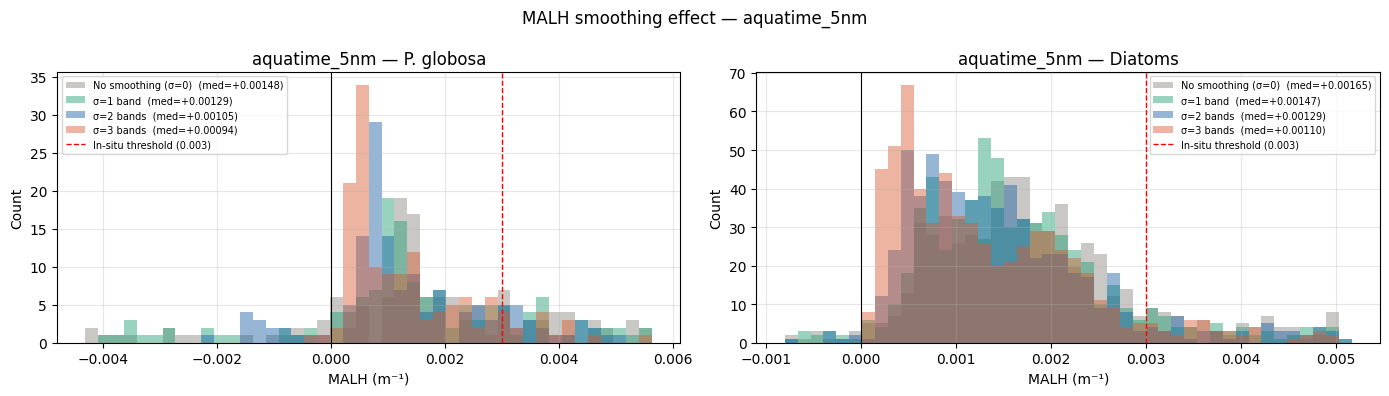

  Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\processed\figures_aquatime\malh_smoothing_aquatime_5nm.png


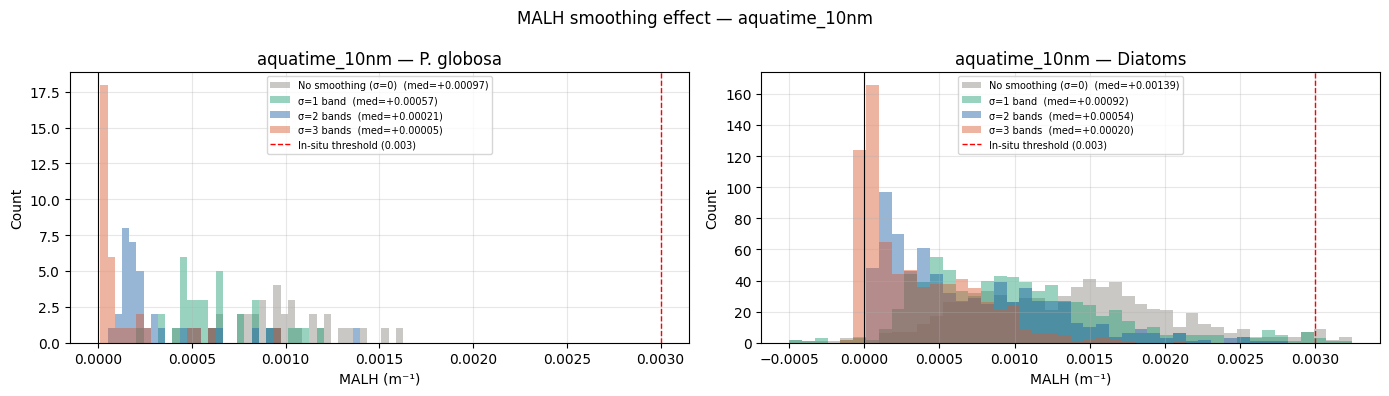

  Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\processed\figures_aquatime\malh_smoothing_aquatime_10nm.png


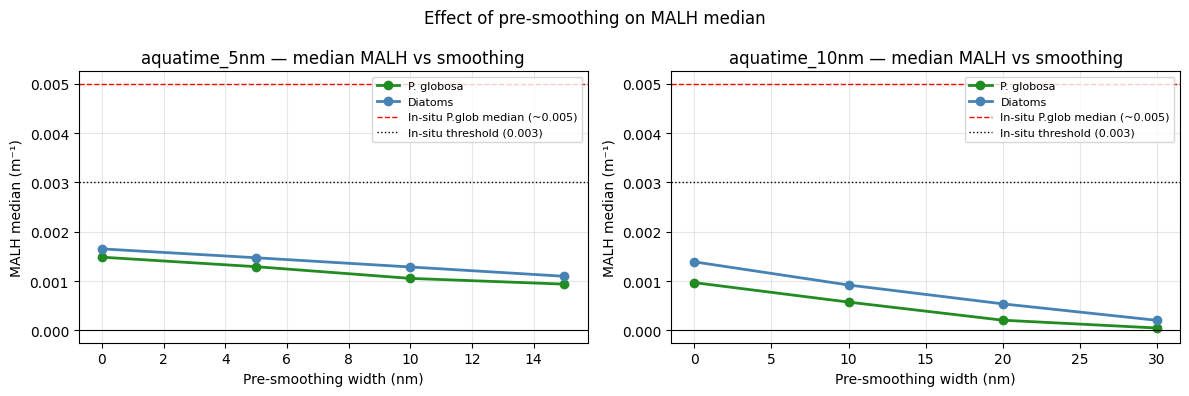


Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\processed\figures_aquatime\malh_smoothing_summary.png

INTERPRETATION
  - If median P.glob crosses zero → smoothing fixes sign issue
  - If median converges toward in-situ ref → smoothing recovers
    the spectral structure blurred by CHIME convolution
  - If misclassification drops with sigma → SNR was the problem
  - Choose the minimum sigma that stabilises the sign without
    over-smoothing the D² feature (check D² figures after applying)


In [18]:
from scipy.ndimage import uniform_filter1d
from scipy.ndimage import gaussian_filter1d

# ── Smoothing widths to test (in number of bands) ────────────────────────────
# For 5 nm data: 1 band = 5 nm; sigma=1 → ±5 nm, sigma=2 → ±10 nm
# For 10 nm data: same sigma values but wider in nm — test anyway for comparison
SIGMA_VALUES = [0, 1, 2, 3]   # 0 = no smoothing (original)

MALH_WL = {"left": 667.0, "peak": 681.0, "right": 715.0}


def compute_MALH_manual(rhow, wl):
    """
    Re-implementation of MALH that snaps to nearest available band.
    Returns scalar MALH value for a single spectrum.
    """
    i_l = int(np.argmin(np.abs(wl - MALH_WL['left'])))
    i_p = int(np.argmin(np.abs(wl - MALH_WL['peak'])))
    i_r = int(np.argmin(np.abs(wl - MALH_WL['right'])))
    wl_l, wl_p, wl_r = wl[i_l], wl[i_p], wl[i_r]
    t = (wl_p - wl_l) / (wl_r - wl_l)
    baseline = rhow[i_l] + t * (rhow[i_r] - rhow[i_l])
    return rhow[i_p] - baseline


print("Computing MALH with pre-smoothing...\n")

results_smooth = {}   # {label: {sigma: array_of_MALH_values}}

for r in RESULTS:
    wl   = r['wl']
    RHOW = r['RHOW']
    PLUB = r['PLUB']
    label = r['label']
    results_smooth[label] = {}

    for sigma in SIGMA_VALUES:
        if sigma == 0:
            RHOW_s = RHOW
        else:
            # Apply Gaussian smoothing along wavelength axis (axis=1)
            RHOW_s = gaussian_filter1d(RHOW, sigma=sigma, axis=1)

        malh_arr = np.array([
            compute_MALH_manual(RHOW_s[i, :], wl)
            for i in range(RHOW_s.shape[0])
        ])
        results_smooth[label][sigma] = malh_arr

    # ── Print median table for this file ─────────────────────────────────────
    print(f"{'─'*60}")
    print(f"  {label}  (Δλ = {r['delta']} nm)")
    print(f"{'─'*60}")
    print(f"  {'Sigma':>6}  {'Smoothing (nm)':>14}  {'P.glob median':>14}  "
          f"{'Diatom median':>14}  {'Misclass (%)':>13}")
    print(f"  {'':─>6}  {'':─>14}  {'':─>14}  {'':─>14}  {'':─>13}")

    for sigma in SIGMA_VALUES:
        malh = results_smooth[label][sigma]
        malh_p  = malh[PLUB == 1]
        malh_d  = malh[PLUB == 0]
        med_p   = np.nanmedian(malh_p) if len(malh_p) > 0 else np.nan
        med_d   = np.nanmedian(malh_d)
        thr_d   = np.nanpercentile(malh_d, 75)
        mc      = np.mean(malh_p <= thr_d) * 100 if len(malh_p) > 0 else np.nan
        nm_smooth = sigma * r['delta']
        sign_ok = '✓' if (not np.isnan(med_p) and med_p > 0) else '✗'
        print(f"  {sigma:>6}  {nm_smooth:>13.1f}  {med_p:>+13.5f} {sign_ok}  "
              f"{med_d:>+13.5f}    {mc:>11.1f}%")
    print(f"  In-situ reference: P.glob ~+0.00500   threshold=0.00300\n")


# ── Figure: distribution evolution with smoothing ────────────────────────────
colors_sigma = ['#888780', '#1D9E75', '#185FA5', '#D85A30']
labels_sigma = ['No smoothing (σ=0)', 'σ=1 band', 'σ=2 bands', 'σ=3 bands']

for r in RESULTS:
    label = r['label']
    PLUB  = r['PLUB']
    phaeo_idx = PLUB == 1
    diatom_idx = PLUB == 0

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
    titles = ['P. globosa', 'Diatoms']
    masks  = [phaeo_idx, diatom_idx]

    for ax, title, mask in zip(axes, titles, masks):
        all_vals = np.concatenate([
            results_smooth[label][s][mask] for s in SIGMA_VALUES
        ])
        p1, p99 = np.nanpercentile(all_vals, [1, 99])
        bins = np.linspace(p1, p99, 45)

        for sigma, color, lbl in zip(SIGMA_VALUES, colors_sigma, labels_sigma):
            vals = results_smooth[label][sigma][mask]
            ax.hist(vals, bins=bins, alpha=0.45, color=color,
                    label=f"{lbl}  (med={np.nanmedian(vals):+.5f})",
                    histtype='stepfilled', linewidth=0.5)

        ax.axvline(0, color='k', lw=0.8)
        ax.axvline(0.003, color='red', ls='--', lw=1.0,
                   label='In-situ threshold (0.003)')
        ax.set(xlabel='MALH (m⁻¹)', ylabel='Count',
               title=f"{label} — {title}")
        ax.legend(fontsize=7); ax.grid(alpha=0.3)

    plt.suptitle(f'MALH smoothing effect — {label}', fontsize=12)
    plt.tight_layout()
    fname = FIG_DIR / f'malh_smoothing_{label}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {fname}")


# ── Figure: median MALH vs sigma for P.globosa ────────────────────────────────
fig, axes = plt.subplots(1, len(RESULTS), figsize=(6 * len(RESULTS), 4))
if len(RESULTS) == 1:
    axes = [axes]

for ax, r in zip(axes, RESULTS):
    label = r['label']
    PLUB  = r['PLUB']
    sigma_nm = [s * r['delta'] for s in SIGMA_VALUES]

    for cls, cls_label, color in [(1, 'P. globosa', 'forestgreen'),
                                   (0, 'Diatoms',    'steelblue')]:
        mask = PLUB == cls
        medians = [
            np.nanmedian(results_smooth[label][s][mask])
            for s in SIGMA_VALUES
        ]
        ax.plot(sigma_nm, medians, 'o-', color=color, lw=2,
                ms=6, label=cls_label)

    ax.axhline(0,     color='k',      lw=0.8, ls='-')
    ax.axhline(0.005, color='red',    lw=1.0, ls='--',
               label='In-situ P.glob median (~0.005)')
    ax.axhline(0.003, color='black',  lw=1.0, ls=':',
               label='In-situ threshold (0.003)')

    ax.set(xlabel='Pre-smoothing width (nm)',
           ylabel='MALH median (m⁻¹)',
           title=f'{label} — median MALH vs smoothing')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Effect of pre-smoothing on MALH median', fontsize=12)
plt.tight_layout()
fname = FIG_DIR / 'malh_smoothing_summary.png'
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved → {fname}")

print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)
print("  - If median P.glob crosses zero → smoothing fixes sign issue")
print("  - If median converges toward in-situ ref → smoothing recovers")
print("    the spectral structure blurred by CHIME convolution")
print("  - If misclassification drops with sigma → SNR was the problem")
print("  - Choose the minimum sigma that stabilises the sign without")
print("    over-smoothing the D² feature (check D² figures after applying)")


MALH TRANSFERABILITY — FINAL DIAGNOSIS

Source                P.glob med  Diatom med    Δ (P−D)   Separable?  Class order OK?
------------------------------------------------------------------------------------
  PANTHYR in-situ       +0.00500    -0.00100   +0.00600        YES ✓          P > D ✓
  aquatime_5nm            +0.00148    +0.00165   -0.00017         NO ✗          D > P ✗  (Cohen's d=-0.11)
  aquatime_10nm           +0.00097    +0.00139   -0.00042         NO ✗          D > P ✗  (Cohen's d=-0.46)

────────────────────────────────────────────────────────────────────────
Root-cause: ρw values at MALH wavelengths by class
────────────────────────────────────────────────────────────────────────
  Source               Class           ρw(667)    ρw(681)    ρw(715)   peak>base?
--------------------------------------------------------------------------------
  aquatime_5nm         P. globosa      0.03727    0.03668    0.02686        YES ✓
  aquatime_5nm         Diatoms         0.03420

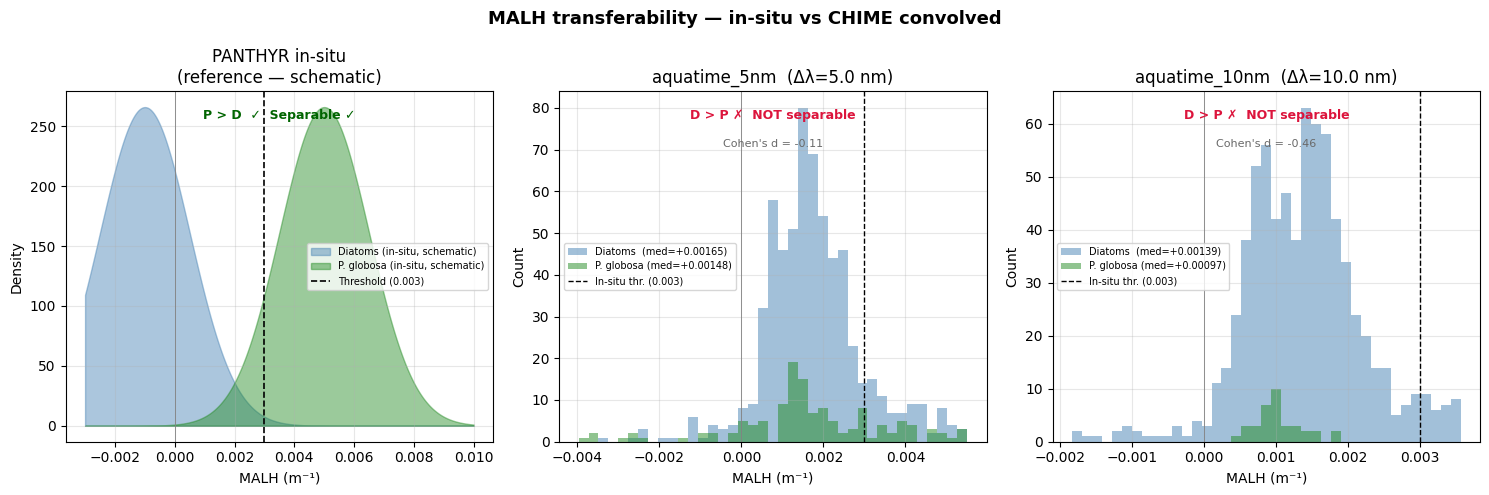


Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\processed\figures_aquatime\malh_transferability_diagnosis.png

CONCLUSION — MALH TRANSFERABILITY TO CHIME

  FUNDAMENTAL PROBLEM
  ───────────────────
  MALH measures the height of the chlorophyll fluorescence peak at ~681 nm
  above a baseline between ~667 nm and ~715 nm.

  In PANTHYR (2.5 nm):  P. globosa has a SHARPER peak at 681 nm than
  diatoms → MALH(P.glob) >> MALH(diatoms) → classes are separable.

  After CHIME convolution:  The narrow fluorescence peak is blurred by the
  CHIME SRF. P. globosa loses its peak advantage. Both classes collapse
  to similar low MALH values with overlapping distributions.
  The class ordering (P > D) is lost or marginal → threshold meaningless.

  SMOOTHING MAKES IT WORSE
  ────────────────────────
  Pre-smoothing further blurs the already-convolved peak. Misclassification
  increases with every sigma step. SNR is not the bottleneck — the

In [19]:
# ── Reference values ──────────────────────────────────────────────────────────
INSITU_PGLOB_MEDIAN = 0.005    # PANTHYR RT1 — P. globosa bloom median
INSITU_DIATOM_MEDIAN = -0.001  # PANTHYR RT1 — Diatoms approximate median
INSITU_THRESHOLD = 0.003       # operational threshold (in-situ)

MALH_WL = {"left": 667.0, "peak": 681.0, "right": 715.0}

def compute_MALH_manual(rhow, wl):
    i_l = int(np.argmin(np.abs(wl - MALH_WL['left'])))
    i_p = int(np.argmin(np.abs(wl - MALH_WL['peak'])))
    i_r = int(np.argmin(np.abs(wl - MALH_WL['right'])))
    wl_l, wl_p, wl_r = wl[i_l], wl[i_p], wl[i_r]
    t = (wl_p - wl_l) / (wl_r - wl_l)
    baseline = rhow[i_l] + t * (rhow[i_r] - rhow[i_l])
    return rhow[i_p] - baseline


# ── 1. Separability analysis ──────────────────────────────────────────────────
print("=" * 72)
print("MALH TRANSFERABILITY — FINAL DIAGNOSIS")
print("=" * 72)

print(f"\n{'Source':<20} {'P.glob med':>11} {'Diatom med':>11} "
      f"{'Δ (P−D)':>10} {'Separable?':>12} {'Class order OK?':>16}")
print("-" * 84)

# In-situ reference row
delta_insitu = INSITU_PGLOB_MEDIAN - INSITU_DIATOM_MEDIAN
print(f"  {'PANTHYR in-situ':<18} {INSITU_PGLOB_MEDIAN:>+11.5f} "
      f"{INSITU_DIATOM_MEDIAN:>+11.5f} {delta_insitu:>+10.5f} "
      f"{'YES ✓':>12} {'P > D ✓':>16}")

diag_rows = []   # collect for figure

for r in RESULTS:
    wl   = r['wl']
    RHOW = r['RHOW']
    PLUB = r['PLUB']

    malh_arr = np.array([compute_MALH_manual(RHOW[i], wl)
                         for i in range(RHOW.shape[0])])

    med_p = np.nanmedian(malh_arr[PLUB == 1]) if (PLUB==1).sum() > 0 else np.nan
    med_d = np.nanmedian(malh_arr[PLUB == 0])
    delta  = med_p - med_d

    # Cohen's d — effect size
    all_std = np.nanstd(malh_arr)
    cohens_d = delta / all_std if all_std > 0 else np.nan

    separable  = abs(cohens_d) > 0.5 if not np.isnan(cohens_d) else False
    order_ok   = (med_p > med_d) if not np.isnan(med_p) else False
    sep_str    = "YES ✓" if separable  else "NO ✗"
    order_str  = "P > D ✓" if order_ok else "D > P ✗"

    print(f"  {r['label']:<20} {med_p:>+11.5f} {med_d:>+11.5f} "
          f"{delta:>+10.5f} {sep_str:>12} {order_str:>16}  "
          f"(Cohen's d={cohens_d:+.2f})")

    diag_rows.append(dict(
        label=r['label'], delta=r['delta'],
        med_p=med_p, med_d=med_d,
        malh_p=malh_arr[PLUB==1], malh_d=malh_arr[PLUB==0],
        cohens_d=cohens_d, order_ok=order_ok
    ))


# ── 2. Root-cause: ρw at MALH bands per class ─────────────────────────────────
print("\n" + "─" * 72)
print("Root-cause: ρw values at MALH wavelengths by class")
print("─" * 72)
print(f"  {'Source':<20} {'Class':<12} {'ρw(667)':>10} "
      f"{'ρw(681)':>10} {'ρw(715)':>10} {'peak>base?':>12}")
print("-" * 80)

for r in RESULTS:
    wl   = r['wl']
    RHOW = r['RHOW']
    PLUB = r['PLUB']
    i_l = int(np.argmin(np.abs(wl - MALH_WL['left'])))
    i_p = int(np.argmin(np.abs(wl - MALH_WL['peak'])))
    i_r = int(np.argmin(np.abs(wl - MALH_WL['right'])))
    wl_l, wl_p, wl_r = wl[i_l], wl[i_p], wl[i_r]
    t = (wl_p - wl_l) / (wl_r - wl_l)

    for cls, cls_lbl in [(1, 'P. globosa'), (0, 'Diatoms')]:
        mask = PLUB == cls
        if mask.sum() == 0:
            continue
        m_l = np.nanmedian(RHOW[mask, i_l])
        m_p = np.nanmedian(RHOW[mask, i_p])
        m_r = np.nanmedian(RHOW[mask, i_r])
        base = m_l + t * (m_r - m_l)
        above = "YES ✓" if m_p > base else "NO ✗"
        print(f"  {r['label']:<20} {cls_lbl:<12} {m_l:>10.5f} "
              f"{m_p:>10.5f} {m_r:>10.5f} {above:>12}")


# ── 3. Figure: side-by-side distributions + in-situ reference ─────────────────
n = len(diag_rows)
fig, axes = plt.subplots(1, n + 1, figsize=(5 * (n + 1), 5))

# Left panel: in-situ reference (schematic)
ax = axes[0]
from scipy.stats import norm
x = np.linspace(-0.003, 0.010, 300)
ax.fill_between(x, norm.pdf(x, INSITU_DIATOM_MEDIAN, 0.0015),
                alpha=0.45, color='steelblue', label='Diatoms (in-situ, schematic)')
ax.fill_between(x, norm.pdf(x, INSITU_PGLOB_MEDIAN, 0.0015),
                alpha=0.45, color='forestgreen', label='P. globosa (in-situ, schematic)')
ax.axvline(INSITU_THRESHOLD, color='k', ls='--', lw=1.2,
           label=f'Threshold ({INSITU_THRESHOLD})')
ax.axvline(0, color='grey', lw=0.6)
ax.set(xlabel='MALH (m⁻¹)', ylabel='Density',
       title='PANTHYR in-situ\n(reference — schematic)')
ax.legend(fontsize=7); ax.grid(alpha=0.3)
ax.text(0.5, 0.92, 'P > D  ✓  Separable ✓',
        transform=ax.transAxes, ha='center', fontsize=9,
        color='darkgreen', fontweight='bold')

# CHIME panels
for ax, row in zip(axes[1:], diag_rows):
    p1 = np.nanpercentile(np.concatenate([row['malh_p'], row['malh_d']]), 1)
    p99 = np.nanpercentile(np.concatenate([row['malh_p'], row['malh_d']]), 99)
    bins = np.linspace(p1, p99, 40)

    ax.hist(row['malh_d'], bins=bins, alpha=0.5, color='steelblue',
            label=f"Diatoms  (med={row['med_d']:+.5f})")
    if len(row['malh_p']) > 0:
        ax.hist(row['malh_p'], bins=bins, alpha=0.5, color='forestgreen',
                label=f"P. globosa (med={row['med_p']:+.5f})")

    ax.axvline(0, color='grey', lw=0.6)
    ax.axvline(INSITU_THRESHOLD, color='k', ls='--', lw=1.0,
               label=f'In-situ thr. ({INSITU_THRESHOLD})')

    color_msg = 'darkgreen' if row['order_ok'] else 'crimson'
    msg = f"P > D ✓" if row['order_ok'] else f"D > P ✗  NOT separable"
    ax.text(0.5, 0.92, msg, transform=ax.transAxes, ha='center',
            fontsize=9, color=color_msg, fontweight='bold')
    ax.text(0.5, 0.84, f"Cohen's d = {row['cohens_d']:+.2f}",
            transform=ax.transAxes, ha='center', fontsize=8,
            color='dimgrey')

    ax.set(xlabel='MALH (m⁻¹)', ylabel='Count',
           title=f"{row['label']}  (Δλ={row['delta']} nm)")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.suptitle('MALH transferability — in-situ vs CHIME convolved',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fname = FIG_DIR / 'malh_transferability_diagnosis.png'
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved → {fname}")


# ── 4. Conclusion block ───────────────────────────────────────────────────────
print("\n" + "=" * 72)
print("CONCLUSION — MALH TRANSFERABILITY TO CHIME")
print("=" * 72)
print("""
  FUNDAMENTAL PROBLEM
  ───────────────────
  MALH measures the height of the chlorophyll fluorescence peak at ~681 nm
  above a baseline between ~667 nm and ~715 nm.

  In PANTHYR (2.5 nm):  P. globosa has a SHARPER peak at 681 nm than
  diatoms → MALH(P.glob) >> MALH(diatoms) → classes are separable.

  After CHIME convolution:  The narrow fluorescence peak is blurred by the
  CHIME SRF. P. globosa loses its peak advantage. Both classes collapse
  to similar low MALH values with overlapping distributions.
  The class ordering (P > D) is lost or marginal → threshold meaningless.

  SMOOTHING MAKES IT WORSE
  ────────────────────────
  Pre-smoothing further blurs the already-convolved peak. Misclassification
  increases with every sigma step. SNR is not the bottleneck — the spectral
  feature itself is destroyed by the sensor SRF.

  WHAT WOULD BE NEEDED TO SALVAGE MALH
  ─────────────────────────────────────
  Option A: Retune reference wavelengths to CHIME band centres and find a
            spectral window where P.glob vs diatom contrast survives
            convolution (may not exist at 5 or 10 nm).
  Option B: Replace MALH with a band-ratio index using CHIME bands that
            retain the red-edge contrast between species.
  Option C: Accept MALH as not applicable to CHIME and rely on D²/Lubac
            for species discrimination.

  RECOMMENDED CONCLUSION FOR THE AQUATIME REPORT
  ────────────────────────────────────────────────
  Algorithm         Transferability    Reason
  ────────────────  ─────────────────  ─────────────────────────────────────
  D²/Lubac          ✓  YES             Shape-based; survives convolution
  MALH              ✗  NO              Fluorescence peak blurred by SRF
  CHL/CRAT          ✗  NO              Red-NIR peak shape destroyed
""")


## 9 — Interpreted report

In [16]:
print('=' * 70)
print('AQUATIME CSV — ALGORITHM PERFORMANCE REPORT')
print('=' * 70)

print('\n── Lubac D² classifier ──────────────────────────────────────────')
for r in RESULTS:
    status = '✅' if r['pct_phaeo'] >= 10 else ('⚠️' if r['pct_phaeo'] > 0 else '❌')
    print(f"  {status} {r['label']:30s} : {r['n_phaeo']:4d}/{r['N']} "
          f"({r['pct_phaeo']:5.1f}%) P. globosa detected")

print('\n── MALH ─────────────────────────────────────────────────────────')
print(f"  In-situ reference threshold : {INSITU_REF['malh_threshold']:.4f} m⁻¹")
for r in RESULTS:
    if np.isnan(r['malh_phaeo_median']):
        print(f"  ❌ {r['label']:30s} : no P. globosa detections")
    else:
        mc = r['misclass_pct']
        status = '✅' if mc < 20 else ('⚠️' if mc < 50 else '❌')
        print(f"  {status} {r['label']:30s} : P.glob median={r['malh_phaeo_median']:+.5f}  "
              f"misclassified={mc:.1f}%  "
              f"suggested threshold={r['candidate_thr']:.5f} m⁻¹")

print('\n── CHL (CRAT) ───────────────────────────────────────────────────')
for r in RESULTS:
    status = '✅' if r['chl_valid'] > 0 else '❌'
    print(f"  {status} {r['label']:30s} : {r['chl_valid']}/{r['N']} valid CHL values")

print('\n── Conclusion ───────────────────────────────────────────────────')
print('  D²  : most transferable — relies on spectral shape, not magnitude')
print('  MALH: requires recalibration — magnitude may differ from in-situ')
print('  CHL : not applicable if turbid-water shape fails CRAT red-peak check')
print('=' * 70)

AQUATIME CSV — ALGORITHM PERFORMANCE REPORT

── Lubac D² classifier ──────────────────────────────────────────
  ✅ aquatime_5nm                   :  141/779 ( 18.1%) P. globosa detected
  ⚠️ aquatime_10nm                  :   36/779 (  4.6%) P. globosa detected

── MALH ─────────────────────────────────────────────────────────
  In-situ reference threshold : 0.0030 m⁻¹
  ⚠️ aquatime_5nm                   : P.glob median=-0.00020  misclassified=37.6%  suggested threshold=-0.00142 m⁻¹
  ✅ aquatime_10nm                  : P.glob median=+0.00253  misclassified=8.3%  suggested threshold=-0.00103 m⁻¹

── CHL (CRAT) ───────────────────────────────────────────────────
  ❌ aquatime_5nm                   : 0/779 valid CHL values
  ❌ aquatime_10nm                  : 0/779 valid CHL values

── Conclusion ───────────────────────────────────────────────────
  D²  : most transferable — relies on spectral shape, not magnitude
  MALH: requires recalibration — magnitude may differ from in-situ
  CHL : n